In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [30]:
df=pd.read_csv("matches.csv")
df

,match_id,date,stage,group,team_1,team_2,score_1,score_2,winner,decided_by_penalties,notes
0,1,2026-06-11,Group Stage,A,Mexico,South Africa,2,0,Mexico,No,Tournament opening match at Estadio Azteca
1,2,2026-06-11,Group Stage,A,South Korea,Czechia,2,1,South Korea,No,NaN
2,3,2026-06-12,Group Stage,B,Canada,Bosnia and Herzegovina,1,1,Draw,No,NaN
3,4,2026-06-12,Group Stage,D,United States,Paraguay,4,1,United States,No,NaN
4,5,2026-06-13,Group Stage,B,Switzerland,Qatar,1,1,Draw,No,NaN
...,...,...,...,...,...,...,...,...,...,...,...
95,96,2026-07-07,Round of 16,NaN,Switzerland,Colombia,0,0,Switzerland,Yes,Switzerland won 4-3 on penalties after 120 sco...
96,97,2026-07-09,Quarterfinal,NaN,France,Morocco,2,0,France,No,Mbappe and Dembele scored; Morocco was first A...
97,98,2026-07-10,Quarterfinal,NaN,Spain,Belgium,2,1,Spain,No,"Fabian Ruiz opened scoring, De Ketelaere equal..."
98,99,2026-07-11,Quarterfinal,NaN,England,Norway,2,1,England,No,Bellingham brace (AET); Norway's Schjelderup o...


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   match_id              100 non-null    int64 
 1   date                  100 non-null    object
 2   stage                 100 non-null    object
 3   group                 72 non-null     object
 4   team_1                100 non-null    object
 5   team_2                100 non-null    object
 6   score_1               100 non-null    int64 
 7   score_2               100 non-null    int64 
 8   winner                100 non-null    object
 9   decided_by_penalties  100 non-null    object
 10  notes                 14 non-null     object
dtypes: int64(3), object(8)
memory usage: 8.7+ KB


/var/folders/wp/hft_4m3d2nx9j8fsn18yl0f40000gn/T/ipykernel_972/4217502748.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="stage", data=df, palette="viridis")


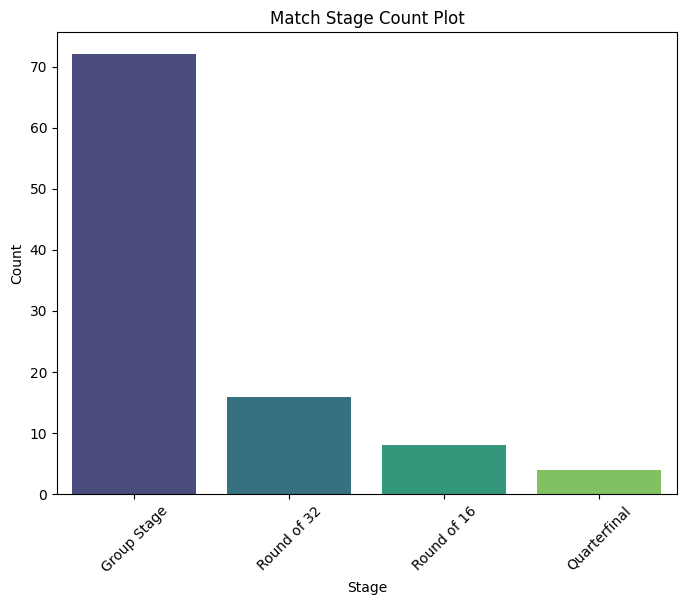

In [32]:
plt.figure(figsize=(8,6))
sns.countplot(x="stage", data=df, palette="viridis")
plt.title("Match Stage Count Plot")
plt.xlabel("Stage")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

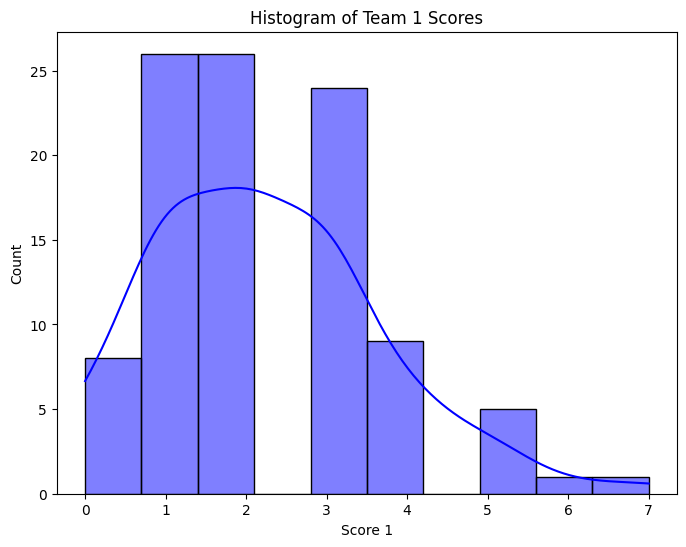

In [33]:
plt.figure(figsize=(8,6))
sns.histplot(df["score_1"].dropna(), bins=10, kde=True, color="blue")
plt.title("Histogram of Team 1 Scores")
plt.xlabel("Score 1")
plt.ylabel("Count")
plt.show()

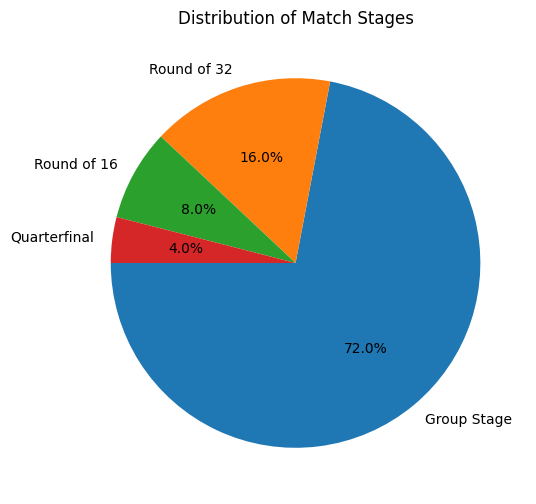

In [34]:
stage = df["stage"].value_counts()

plt.figure(figsize=(8,6))
plt.pie(
    stage,
    labels=stage.index,
    autopct="%1.1f%%",
    startangle=180
)

plt.title("Distribution of Match Stages")
plt.show()

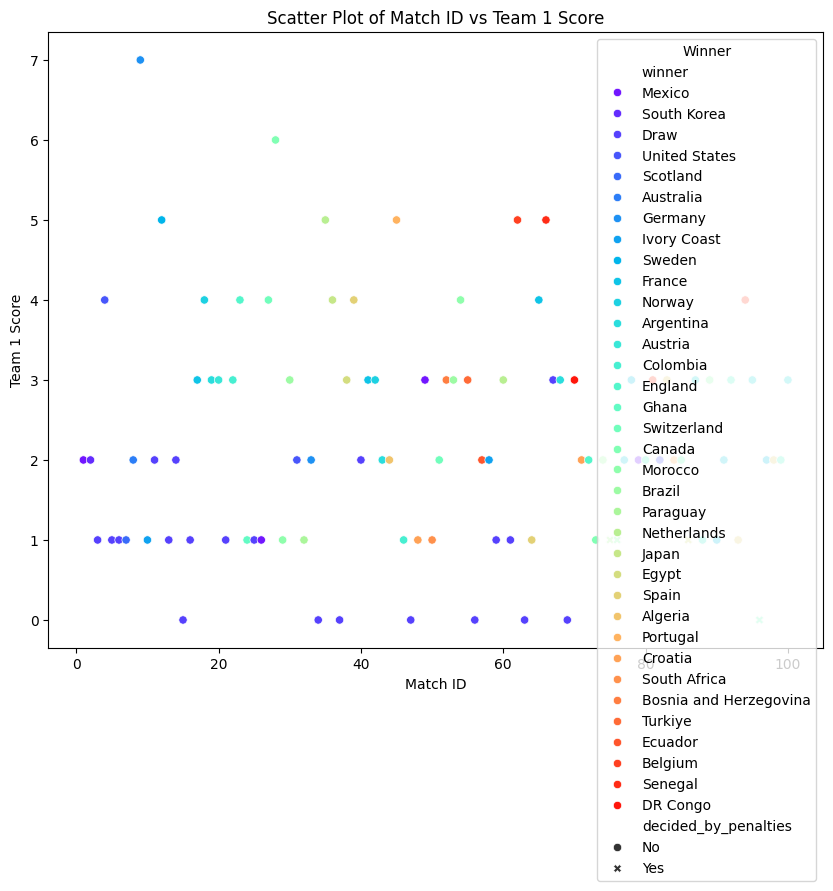

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.scatterplot(
    x="match_id",
    y="score_1",
    data=df,
    hue="winner",
    style="decided_by_penalties",
    palette="rainbow"
)

plt.title("Scatter Plot of Match ID vs Team 1 Score")
plt.xlabel("Match ID")
plt.ylabel("Team 1 Score")
plt.legend(title="Winner")

plt.show()

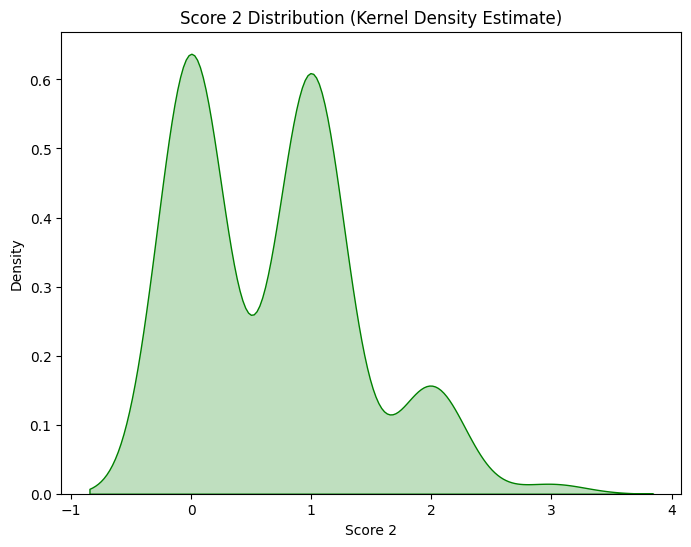

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.kdeplot(data=df["score_2"].dropna(), color="green", fill=True)

plt.title("Score 2 Distribution (Kernel Density Estimate)")
plt.xlabel("Score 2")
plt.ylabel("Density")

plt.show()

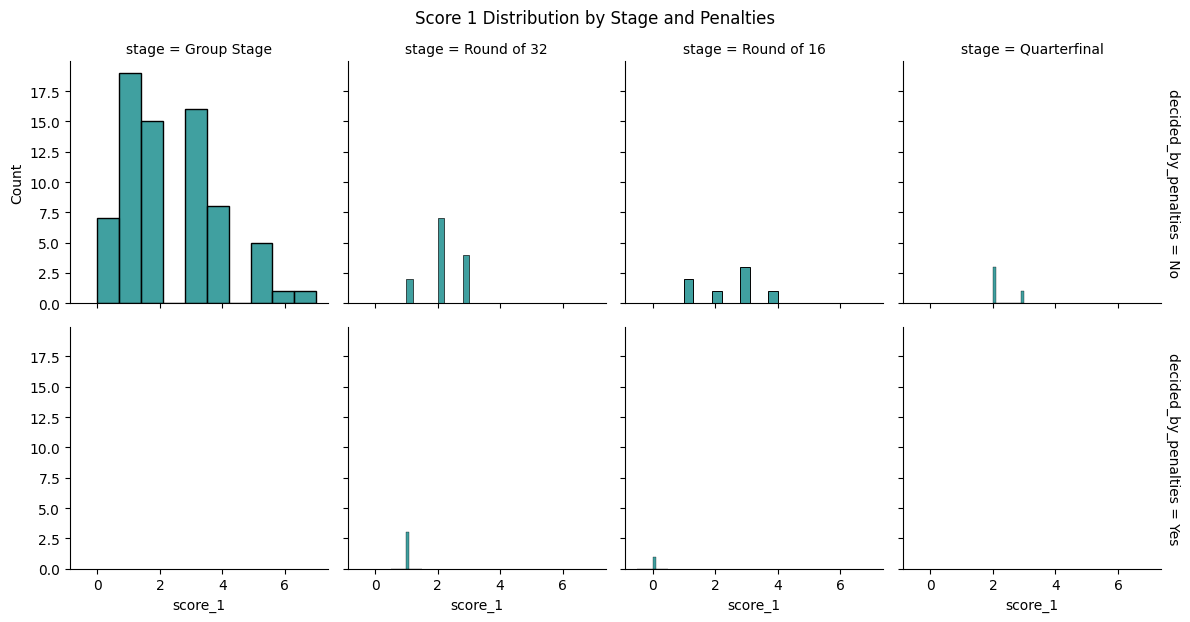

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

g = sns.FacetGrid(df, col="stage", row="decided_by_penalties", margin_titles=True)
g.map(sns.histplot, "score_1", bins=10, color="teal")

g.fig.suptitle("Score 1 Distribution by Stage and Penalties", y=1.03)

plt.show()